
# Practice Notebook: Preprocessing and Feature Engineering

This notebook provides hands-on exercises to practice:
- Data preprocessing
- Missing value handling
- Feature scaling
- Normalization
- Outlier detection
- Feature engineering
- Feature binning
- Polynomial features
- Correlation analysis

All examples use numerical real-world datasets.



# Real-World Scenario

You are working for a healthcare analytics company.

The company collects numerical health data:
- Age
- Weight
- Exercise hours
- Sleep hours
- Water intake
- Blood pressure
- Cholesterol

Your task is to preprocess the dataset and engineer useful features for machine learning.


In [68]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(42)


In [69]:

# Create sample dataset

n = 120

data = pd.DataFrame({
    'age': np.random.randint(18, 70, n),
    'weight': np.random.normal(75, 15, n),
    'exercise_hours': np.random.uniform(0, 4, n),
    'sleep_hours': np.random.uniform(4, 10, n),
    'water_intake': np.random.uniform(1, 5, n),
    'blood_pressure': np.random.normal(120, 15, n),
    'cholesterol': np.random.normal(190, 35, n)
})

data['health_score'] = (
    100
    - data['age'] * 0.2
    - data['weight'] * 0.1
    + data['exercise_hours'] * 5
    + data['sleep_hours'] * 2
    + data['water_intake'] * 3
    - data['blood_pressure'] * 0.1
    - data['cholesterol'] * 0.05
    + np.random.normal(0, 3, n)
)

# Add missing values
data.loc[5, 'weight'] = np.nan
data.loc[20, 'sleep_hours'] = np.nan
data.loc[50, 'cholesterol'] = np.nan

data.head()


,age,weight,exercise_hours,sleep_hours,water_intake,blood_pressure,cholesterol,health_score
0,56,84.934268,0.715291,9.877063,2.620808,138.182346,208.064366,87.607324
1,69,78.616832,1.465875,5.051982,3.285892,117.839261,206.642277,82.961484
2,46,72.476924,2.976682,4.102967,3.963895,121.920616,169.918617,99.386731
3,32,92.471530,2.883760,8.580187,4.068779,112.779925,166.173950,107.668567
4,60,71.313785,1.232243,8.841478,4.291161,102.779176,215.982772,100.754112


# Exercise 1: Dataset Exploration

## Tasks
1. Display first 10 rows
2. Display dataset shape
3. Display summary statistics
4. Identify numerical columns

In [70]:
# Write your solution here
print('First 10 rows:',data.head(10))  #1 Display the first 10 rows of the dataset
print('Shape of Dataset:', data.shape)  #2 Display the shape of the dataset
print('Summary Statistics:',data.describe())  #3 Display summary statistics of the dataset
print('Numeric Columns:',data.select_dtypes(include=np.number).columns)  #4 Identify all numeric columns in the dataset

First 10 rows:    age     weight  exercise_hours  sleep_hours  water_intake  blood_pressure  \
0   56  84.934268        0.715291     9.877063      2.620808      138.182346   
1   69  78.616832        1.465875     5.051982      3.285892      117.839261   
2   46  72.476924        2.976682     4.102967      3.963895      121.920616   
3   32  92.471530        2.883760     8.580187      4.068779      112.779925   
4   60  71.313785        1.232243     8.841478      4.291161      102.779176   
5   25        NaN        2.170161     6.077826      3.976847      110.966157   
6   38  93.182585        2.035256     6.788043      3.724158       92.710493   
7   56  93.502452        2.545330     7.898642      1.950026      133.719083   
8   36  51.387671        1.001847     4.288354      2.600892       87.376762   
9   40  84.569294        2.359483     9.694874      2.910860      150.482138   

   cholesterol  health_score  
0   208.064366     87.607324  
1   206.642277     82.961484  
2   169.918

# Exercise 2: Missing Values

## Tasks
1. Find missing values
2. Count missing values
3. Identify columns with missing values

In [71]:
# Write your solution here
#1. Identify missing values in the dataset
print('Missing Values in the Dataset:')
print(data.isnull())  #1 Identify missing values in the dataset

#2. Count missing values in each column of the dataset
print('Count of Missing Values in Each Column:')
print(data.isnull().sum())  #2 Count missing values in each column of the dataset

#3. List columns that contain missing values
print('Columns with Missing Values:')
print(data.columns[data.isnull().any()])  #3 List columns that contain missing values


Missing Values in the Dataset:
       age  weight  exercise_hours  sleep_hours  water_intake  blood_pressure  \
0    False   False           False        False         False           False   
1    False   False           False        False         False           False   
2    False   False           False        False         False           False   
3    False   False           False        False         False           False   
4    False   False           False        False         False           False   
..     ...     ...             ...          ...           ...             ...   
115  False   False           False        False         False           False   
116  False   False           False        False         False           False   
117  False   False           False        False         False           False   
118  False   False           False        False         False           False   
119  False   False           False        False         False           False 

# Exercise 3: Handle Missing Values

## Tasks
1. Create a SimpleImputer
2. Replace missing values using mean
3. Verify no missing values remain

In [72]:
# Write your solution here
#1. Impute missing values in the dataset using mean imputation
imputer = SimpleImputer(strategy='mean')

#2. Create a new DataFrame with imputed values, ensuring the original column names are retained
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)  

#Verify
data_imputed.isnull().sum()

#3. Display the first 5 rows of the imputed dataset to verify the changes
print('First 5 rows of the imputed dataset:')
print(data_imputed.head())  


First 5 rows of the imputed dataset:
    age     weight  exercise_hours  sleep_hours  water_intake  blood_pressure  \
0  56.0  84.934268        0.715291     9.877063      2.620808      138.182346   
1  69.0  78.616832        1.465875     5.051982      3.285892      117.839261   
2  46.0  72.476924        2.976682     4.102967      3.963895      121.920616   
3  32.0  92.471530        2.883760     8.580187      4.068779      112.779925   
4  60.0  71.313785        1.232243     8.841478      4.291161      102.779176   

   cholesterol  health_score  
0   208.064366     87.607324  
1   206.642277     82.961484  
2   169.918617     99.386731  
3   166.173950    107.668567  
4   215.982772    100.754112  


# Exercise 4: Standardization

## Tasks
1. Separate features
2. Apply StandardScaler
3. Create scaled DataFrame
4. Display first 5 rows

In [73]:
# Write your solution here
# Standardization converts data to:
# Mean = 0
# Standard deviation = 1

#1. Separate features
X = data_imputed.drop("health_score", axis=1)

#2. Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#3. Create a new DataFrame with standardized features, ensuring the original column names are retained
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()



,age,weight,exercise_hours,sleep_hours,water_intake,blood_pressure,cholesterol
0,0.874274,0.689871,-0.986587,1.582938,-0.332863,1.151206,0.456451
1,1.736935,0.260559,-0.325065,-1.289318,0.247769,-0.161434,0.420393
2,0.210688,-0.156689,1.006473,-1.854244,0.839681,0.101916,-0.510753
3,-0.718331,1.202078,0.924576,0.810938,0.931246,-0.487889,-0.605701
4,1.139708,-0.235732,-0.530975,0.966479,1.125391,-1.133188,0.657226


# Exercise 5: Normalization

## Tasks
1. Apply MinMaxScaler
2. Normalize feature values between 0 and 1
3. Display normalized dataset

In [74]:
# Write your solution here
#1.Apply Min Max scaling : Min-Max Scaling converts data to a range of [0, 1]
minmax = MinMaxScaler()
X_normalized = minmax.fit_transform(X)

#2. Create a new DataFrame with normalized features, ensuring the original column names are retained
X_normalized_df = pd.DataFrame(X_normalized, columns=X.columns)

#3.Display the first 5 rows of the normalized dataset to verify the changes
print('First 5 rows of the normalized dataset:')
print(X_normalized_df.head())

First 5 rows of the normalized dataset:
        age    weight  exercise_hours  sleep_hours  water_intake  \
0  0.745098  0.702980        0.175504     0.983255      0.398642   
1  1.000000  0.619386        0.365167     0.163187      0.567933   
2  0.549020  0.538141        0.746929     0.001893      0.740513   
3  0.274510  0.802715        0.723448     0.762839      0.767210   
4  0.823529  0.522750        0.306131     0.807247      0.823816   

   blood_pressure  cholesterol  
0        0.779128     0.572966  
1        0.467323     0.565913  
2        0.529879     0.383778  
3        0.389777     0.365206  
4        0.236492     0.612238  


# Exercise 6: Outlier Detection

## Tasks
1. Create boxplot for weight
2. Create boxplot for cholesterol
3. Identify possible outliers

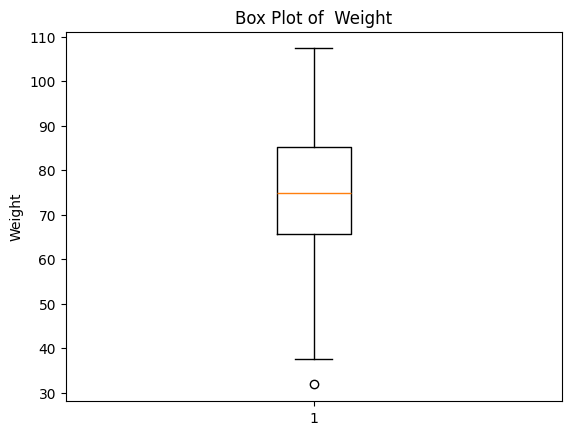

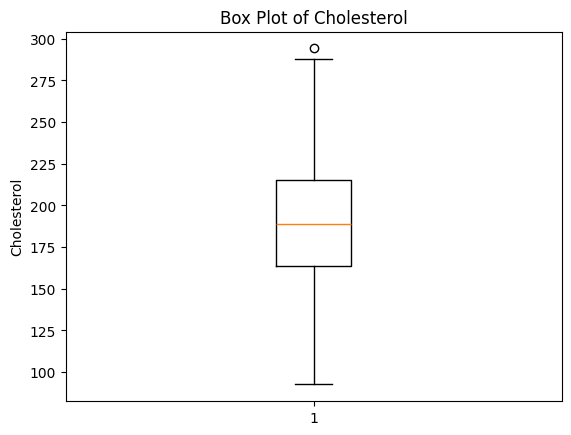

In [75]:
# Write your solution here
#1. Create a box plot for the 'weight' feature in the normalized dataset to visualize its distribution and identify any outliers
plt.boxplot(data_imputed['weight'])
plt.title('Box Plot of  Weight')
plt.ylabel('Weight')
plt.show()

#2. Create a boxplot for the 'cholesterol' feature in the normalized dataset to visualize its distribution
plt.boxplot(data_imputed['cholesterol'])
plt.title('Box Plot of Cholesterol')
plt.ylabel('Cholesterol')
plt.show()




# Exercise 7: Feature Engineering

## Tasks
Create:
1. fitness_score = exercise_hours * sleep_hours
2. hydration_score = water_intake * sleep_hours
3. weight_age_ratio = weight / age

In [76]:
# Write your solution here
#1. Create fitness score by combining 'exercise_hours' and 'sleep_hours'features
data_imputed['fitness_score'] = data_imputed['exercise_hours'] * data_imputed['sleep_hours']
print('First 5 rows of the dataset with fitness score:')
print(data_imputed.head())

#2.Create hydration score by combining 'water_intake' and 'sleep' features
data_imputed['hydration_score'] = data_imputed['water_intake'] * data_imputed['sleep_hours']
print('First 5 rows of the dataset with hydration score:')
print(data_imputed.head())

#3. Create weight-age ratio by dividing 'weight' by 'age'
data_imputed['weight_age_ratio'] = data_imputed['weight'] / data_imputed['age']
print('First 5 rows of the dataset with weight-age ratio:')
print(data_imputed.head())


First 5 rows of the dataset with fitness score:
    age     weight  exercise_hours  sleep_hours  water_intake  blood_pressure  \
0  56.0  84.934268        0.715291     9.877063      2.620808      138.182346   
1  69.0  78.616832        1.465875     5.051982      3.285892      117.839261   
2  46.0  72.476924        2.976682     4.102967      3.963895      121.920616   
3  32.0  92.471530        2.883760     8.580187      4.068779      112.779925   
4  60.0  71.313785        1.232243     8.841478      4.291161      102.779176   

   cholesterol  health_score  fitness_score  
0   208.064366     87.607324       7.064973  
1   206.642277     82.961484       7.405574  
2   169.918617     99.386731      12.213227  
3   166.173950    107.668567      24.743196  
4   215.982772    100.754112      10.894851  
First 5 rows of the dataset with hydration score:
    age     weight  exercise_hours  sleep_hours  water_intake  blood_pressure  \
0  56.0  84.934268        0.715291     9.877063      2.620

# Exercise 8: Feature Binning

## Tasks
1. Create sleep quality categories
2. Use labels:
   - Low
   - Medium
   - High
3. Display category column

In [77]:
# Write your solution here
#1.2.3.Create sleep quality categories by creating bins for sleep hours and labeling them as 'Low', 'Medium', and 'High' and then displaying it.
bins = [0, 6, 8, 12]
labels = [
    "Low",
    "Medium",
    "High"
]

data_imputed["sleep_quality"] = pd.cut(
    data_imputed["sleep_hours"],
    bins=bins,
    labels=labels
)

data_imputed[
    ["sleep_hours", "sleep_quality"]
].head()





,sleep_hours,sleep_quality
0,9.877063,High
1,5.051982,Low
2,4.102967,Low
3,8.580187,High
4,8.841478,High


# Exercise 9: Polynomial Features

## Tasks
1. Create polynomial features
2. Use age and weight
3. Use degree = 2
4. Display generated features

In [78]:
# Write your solution here

poly_features = data_imputed[
    ["age", "weight"]
]
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

poly_data = poly.fit_transform(poly_features)

poly_names = poly.get_feature_names_out(
    ["age", "weight"]
)

poly_df = pd.DataFrame(
    poly_data,
    columns=poly_names
)

poly_df.head()


,age,weight,age^2,age weight,weight^2
0,56.0,84.934268,3136.0,4756.318991,7213.829830
1,69.0,78.616832,4761.0,5424.561438,6180.606343
2,46.0,72.476924,2116.0,3333.938489,5252.904466
3,32.0,92.471530,1024.0,2959.088950,8550.983802
4,60.0,71.313785,3600.0,4278.827081,5085.655887


# Exercise 10: Correlation Analysis

## Tasks
1. Create correlation matrix
2. Visualize correlations
3. Identify strongest correlations

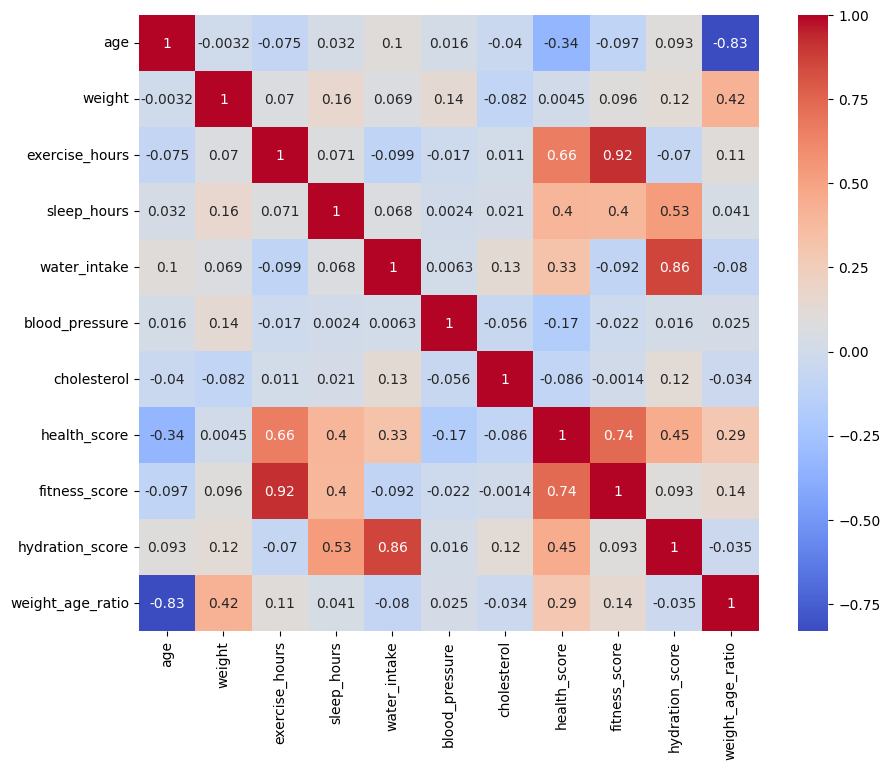

health_score        1.000000
fitness_score       0.735376
exercise_hours      0.661561
hydration_score     0.452194
sleep_hours         0.403987
water_intake        0.325285
weight_age_ratio    0.292973
weight              0.004486
cholesterol        -0.086290
blood_pressure     -0.169944
age                -0.335732
Name: health_score, dtype: float64

In [79]:
# Write your solution here
corr_matrix = data_imputed.corr(
    numeric_only=True
)

corr_matrix

#2. Visualize the correlation matrix using a heatmap
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.show()

#3. Strongest correlations
corr_matrix["health_score"]\
    .sort_values(
        ascending=False
    )



# Mini Project

## Scenario

You are preparing data for a machine learning model.

## Tasks

1. Handle missing values
2. Scale features
3. Create at least 3 engineered features
4. Detect outliers
5. Create polynomial features
6. Analyze correlations
7. Write conclusions about:
   - Important features
   - Useful preprocessing methods


First 5 Rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Shape:
(150, 5)

Summary Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Missing Values:

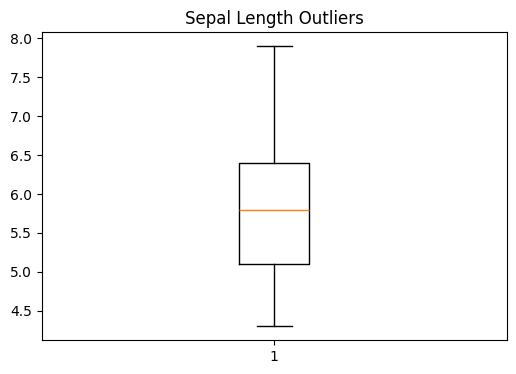

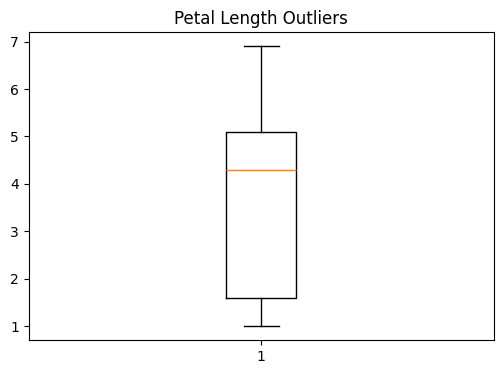


Polynomial Features:
   sepal_length  petal_length  sepal_length^2  sepal_length petal_length  \
0           5.1           1.4           26.01                       7.14   
1           4.9           1.4           24.01                       6.86   
2           4.7           1.3           22.09                       6.11   
3           4.6           1.5           21.16                       6.90   
4           5.0           1.4           25.00                       7.00   

   petal_length^2  
0            1.96  
1            1.96  
2            1.69  
3            2.25  
4            1.96  

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width  \
sepal_length      1.000000    -0.110684      0.864182     0.814904   
sepal_width      -0.110684     1.000000     -0.430034    -0.361266   
petal_length      0.864182    -0.430034      1.000000     0.958118   
petal_width       0.814904    -0.361266      0.958118     1.000000   
petal_ratio      -0.569140    

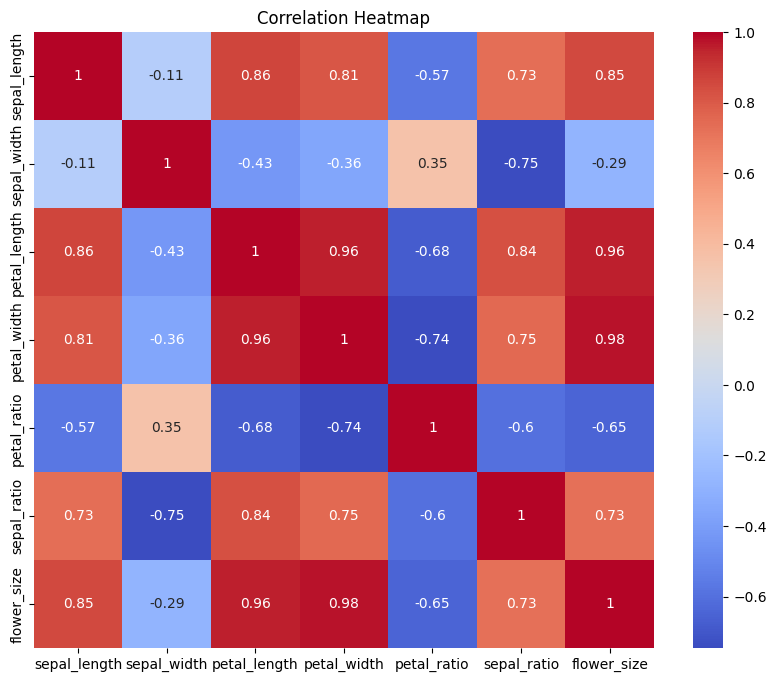

In [ ]:
# Write your mini project solution here
    # For my mini project I will use iris dataset which is a commonly used dataset in machine learning.
    # It contains measurements of iris flowers and is often used for classification tasks.
    # The dataset includes features such as sepal length, sepal width, petal length, and petal width, 
    # along with the corresponding species of iris flower. I will perform preprocessing and feature engineering on this dataset 
    # to prepare it for the machine learning model. I will conclude my findings in markdown format at the end of the notebook.
#=====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures


#Load Iris Dataset

iris = pd.read_csv("/Users/rukku/Documents/Sheridan/Python/PythonProject/iris.csv")
print("First 5 Rows:")
print(iris.head())
print("\nDataset Shape:")
print(iris.shape)
print("\nSummary Statistics:")
print(iris.describe())

#Find and Handle Missing Values

iris.loc[5, 'sepal_length'] = np.nan
iris.loc[20, 'petal_width'] = np.nan
iris.loc[50, 'petal_length'] = np.nan
print("\nMissing Values:")
print(iris.isnull().sum())

#Scale numeric features using mean imputation for missing values
numeric_cols = iris.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='mean')
iris[numeric_cols] = imputer.fit_transform(
    iris[numeric_cols]
)
print("\nMissing Values After Imputation:")
print(iris.isnull().sum())


#Feature Engineering - Create 3 new feat
iris['petal_ratio'] = (
    iris['petal_length']
    / iris['petal_width']
)

iris['sepal_ratio'] = (
    iris['sepal_length']
    / iris['sepal_width']
)

iris['flower_size'] = (
    iris['petal_length']
    * iris['petal_width']
)

print("\nEngineered Features:")
print(
    iris[
        [
            'petal_ratio',
            'sepal_ratio',
            'flower_size'
        ]
    ].head()
)



#Scaling using StandardScaler

features = iris.select_dtypes(
    include=np.number
)

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    features
)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

print("\nScaled Data:")
print(scaled_df.head())


#Outlier Detection using Boxplots

plt.figure(figsize=(6,4))
plt.boxplot(iris['sepal_length'])
plt.title("Sepal Length Outliers")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(iris['petal_length'])
plt.title("Petal Length Outliers")
plt.show()

#Create polynomial features to capture nonlinear relationships

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

poly_data = poly.fit_transform(
    iris[
        [
            'sepal_length',
            'petal_length'
        ]
    ]
)

poly_columns = poly.get_feature_names_out(
    [
        'sepal_length',
        'petal_length'
    ]
)

poly_df = pd.DataFrame(
    poly_data,
    columns=poly_columns
)

print("\nPolynomial Features:")
print(poly_df.head())

#Perform correlation analysis to identify relationships between features
corr_matrix = iris.select_dtypes(
    include=np.number
).corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

#Conclusions in Markdown

Mini Project Conclusion: 
In this mini project, I used the Iris dataset and applied several data preprocessing techniques to prepare the data for machine learning.

First, I handled missing values using mean imputation so that the dataset had no missing data. I then scaled the numerical features using StandardScaler to ensure all features were on a similar scale.

I then created three new features: petal_ratio, sepal_ratio, and flower_size. These engineered features provide additional information about the flowers and may help improve model performance.

Outlier detection was performed using boxplots for sepal length and petal length. No significant outliers were observed because there were no data points outside the whiskers. This suggests that the Iris dataset is relatively clean and does not require outlier treatment.

Polynomial features were also generated using sepal length and petal length to capture more complex relationships between variables.

Correlation Analysis:
Correlation analysis showed that petal length and petal width have a very strong positive correlation (0.96). This means flowers with longer petals generally have wider petals. The engineered feature flower_size also showed strong correlations with petal measurements, suggesting it may be useful for machine learning models.

    Strong Positive Correlations:
    petal_length ↔ petal_width = 0.96

    Flowers with longer petals usually have wider petals.
    flower_size ↔ petal_width = 0.98

    The engineered feature flower_size is strongly related to petal width.
    flower_size ↔ petal_length = 0.96

    Flower size increases as petal length increases.

    Moderate Positive Correlations:
    sepal_length ↔ petal_length = 0.86
    sepal_length ↔ flower_size = 0.85

    Negative Correlations:
    petal_ratio ↔ petal_width = -0.74
    sepal_ratio ↔ sepal_width = -0.75

These negative correlations indicate that as one feature increases, the other tends to decrease.

Important Features

Based on the correlation analysis, petal length, petal width, and the engineered feature flower_size appear to be the most important features because they show the strongest relationships with other variables in the dataset.

Useful Preprocessing Methods: The most useful preprocessing methods used in this project were:

    Handling missing values using mean imputation
    Feature scaling using StandardScaler
    Feature engineering to create new meaningful features
    Outlier detection using boxplots
    Polynomial feature generation
    Correlation analysis to identify relationships between features
    Conclusion

Overall, feature scaling, feature engineering, and correlation analysis helped make the dataset more suitable for machine learning and provided additional insights into the relationships between flower measurements.

In conclusion, preprocessing helped clean and transform the data, while feature engineering created more meaningful variables that could be useful for building a machine learning model.